# 🏎️ Nina's F1 Predictions: 2026 Japanese Grand Prix (Round 3)
## Suzuka Circuit — March 27-29, 2026

**Model version:** v0.3 (XGBoost + rolling features)  
**Upgrade from v0.2:** Switched from ELO composite scoring to XGBoost gradient boosting — the gold standard for F1 prediction (77-82% winner accuracy in research).  
**Data:** 59 races (2023-2026), 1,182 driver-race entries  
**Last updated:** March 24, 2026

### Why XGBoost?
Research from GWU and community models shows XGBoost outperforms ELO, logistic regression, and random forests for F1 prediction. It automatically identifies feature importance and handles non-linear relationships between grid position, constructor strength, and race outcomes.

### 2026 Regulation Context
New power units (50/50 electric/ICE), active aerodynamics, smaller/lighter cars. Pre-2026 data is discounted but still useful for driver skill. The model uses a `is_2026` flag to let XGBoost learn the regulation shift.


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)


## 1. Data Loading
Training data from 59 races across 2023-2026. No API calls — loading from cached CSV.


In [2]:
df = pd.read_csv('../data/all_results.csv')
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['DNF'] = df['Status'].apply(lambda x: 0 if x == 'Finished' or (isinstance(x, str) and 'Lap' in x) else 1)
df = df.sort_values(['Year', 'Round', 'Position']).reset_index(drop=True)

print(f"Loaded {len(df)} entries across {df[['Year','Round']].drop_duplicates().shape[0]} races")
print(f"\nRaces by year:")
for year, g in df.groupby('Year'):
    flag = '🟢' if year == 2026 else '🟡'
    print(f"  {flag} {year}: {g[['Round']].drop_duplicates().shape[0]} races")


Loaded 1182 entries across 59 races

Races by year:
  🟡 2023: 22 races
  🟡 2024: 24 races
  🟡 2025: 11 races
  🟢 2026: 2 races


## 2. Feature Engineering

Building rolling features that capture recent form, constructor strength, and driver skill. These are the features XGBoost will learn from.

| Feature | Description | Why It Matters |
|---------|-------------|----------------|
| `grid_position` | Qualifying result | #1 predictor (0.375 importance) |
| `constructor_avg_finish` | Team's rolling avg finish (5 races) | Car performance |
| `driver_avg_finish` | Driver's rolling avg finish (5 races) | Recent form |
| `driver_avg_grid` | Driver's rolling avg grid (5 races) | Qualifying pace |
| `positions_gained_avg` | Avg positions gained per race (5 races) | Racecraft |
| `teammate_delta` | Avg position gap vs teammate (5 races) | Relative skill |
| `dnf_rate` | DNF proportion (last 10 races) | Reliability |
| `track_experience` | Times raced at this circuit | Track knowledge |
| `is_2026` | New regulation flag | Regime change |


In [3]:
# Sort chronologically
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)

# Create unique race identifier
df['race_id'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
race_order = df[['race_id', 'Year', 'Round']].drop_duplicates().sort_values(['Year', 'Round']).reset_index(drop=True)
race_order['race_seq'] = range(len(race_order))
df = df.merge(race_order[['race_id', 'race_seq']], on='race_id')

# Rolling features per driver
features_list = []

for race_seq in sorted(df['race_seq'].unique()):
    race_data = df[df['race_seq'] == race_seq].copy()
    
    for _, row in race_data.iterrows():
        driver = row['FullName']
        team = row['TeamName']
        race_name = row['RaceName']
        
        # Historical data for this driver (before this race)
        hist = df[(df['FullName'] == driver) & (df['race_seq'] < race_seq)]
        hist_team = df[(df['TeamName'] == team) & (df['race_seq'] < race_seq)]
        
        # Rolling averages (last 5 races)
        last5 = hist.tail(5)
        last5_team = hist_team.tail(5)
        last10 = hist.tail(10)
        
        # Teammate delta
        teammate_hist = df[(df['TeamName'] == team) & (df['FullName'] != driver) & (df['race_seq'] < race_seq)]
        tm_races = []
        for seq in hist.tail(5)['race_seq'].values:
            my_pos = hist[hist['race_seq'] == seq]['Position'].values
            tm_pos = teammate_hist[teammate_hist['race_seq'] == seq]['Position'].values
            if len(my_pos) > 0 and len(tm_pos) > 0 and not np.isnan(my_pos[0]) and not np.isnan(tm_pos[0]):
                tm_races.append(tm_pos[0] - my_pos[0])  # positive = beating teammate
        
        # Track experience
        track_hist = hist[hist['RaceName'] == race_name]
        
        features_list.append({
            'race_seq': race_seq,
            'Year': row['Year'],
            'Round': row['Round'],
            'RaceName': race_name,
            'FullName': driver,
            'TeamName': team,
            'grid_position': row['GridPosition'],
            'finish_position': row['Position'],
            'constructor_avg_finish': last5_team['Position'].mean() if len(last5_team) > 0 else 12.0,
            'driver_avg_finish': last5['Position'].mean() if len(last5) > 0 else 12.0,
            'driver_avg_grid': last5['GridPosition'].mean() if len(last5) > 0 else 12.0,
            'positions_gained_avg': (last5['GridPosition'] - last5['Position']).mean() if len(last5) > 0 else 0.0,
            'teammate_delta': np.mean(tm_races) if len(tm_races) > 0 else 0.0,
            'dnf_rate': last10['DNF'].mean() if len(last10) > 0 else 0.1,
            'track_experience': len(track_hist),
            'is_2026': 1 if row['Year'] == 2026 else 0,
            'DNF': row['DNF']
        })

feat_df = pd.DataFrame(features_list)
feat_df = feat_df.dropna(subset=['finish_position', 'grid_position'])

print(f"Feature matrix: {feat_df.shape[0]} entries × {len([c for c in feat_df.columns if c not in ['race_seq','Year','Round','RaceName','FullName','TeamName','finish_position','DNF']])} features")
print(f"\nFeature sample (2026 R01, top 5):")
sample = feat_df[(feat_df['Year'] == 2026) & (feat_df['Round'] == 1)].head(5)
print(sample[['FullName', 'grid_position', 'constructor_avg_finish', 'driver_avg_finish', 'teammate_delta']].to_string(index=False))


Feature matrix: 1181 entries × 9 features

Feature sample (2026 R01, top 5):
       FullName  grid_position  constructor_avg_finish  driver_avg_finish  teammate_delta
 George Russell            1.0                     9.2                5.6             9.8
 Kimi Antonelli            2.0                     9.2               15.4            -9.8
Charles Leclerc            4.0                     4.8                3.8             1.2
 Lewis Hamilton            7.0                     4.8                5.0            -1.2
   Lando Norris            6.0                     5.4                4.8            -2.2


## 3. XGBoost Model

Training on 2023-2025 data, validating on 2026 Rounds 1-2. The model predicts finishing position from the engineered features.


In [4]:
# Split: train on pre-2026, validate on 2026
feature_cols = ['grid_position', 'constructor_avg_finish', 'driver_avg_finish', 
                'driver_avg_grid', 'positions_gained_avg', 'teammate_delta',
                'dnf_rate', 'track_experience', 'is_2026']

train = feat_df[feat_df['Year'] < 2026].copy()
val = feat_df[feat_df['Year'] == 2026].copy()

# Remove DNFs from training targets (they skew position predictions)
train_clean = train[train['DNF'] == 0].copy()
val_clean = val[val['DNF'] == 0].copy()

X_train = train_clean[feature_cols].fillna(0)
y_train = train_clean['finish_position']
X_val = val_clean[feature_cols].fillna(0)
y_val = val_clean['finish_position']

# Train XGBoost
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

train_mae = mean_absolute_error(y_train, train_pred)
val_mae = mean_absolute_error(y_val, val_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("=" * 60)
print("  🤖 XGBOOST MODEL PERFORMANCE")
print("=" * 60)
print(f"\n  Training (2023-2025):  MAE = {train_mae:.2f} positions, RMSE = {train_rmse:.2f}")
print(f"  Validation (2026 R1-R2): MAE = {val_mae:.2f} positions, RMSE = {val_rmse:.2f}")
print(f"\n  Interpretation: The model predicts finishing position")
print(f"  within ~{val_mae:.1f} positions on average for 2026 races.")

# Residual std for Monte Carlo noise calibration
residual_std = np.std(y_val.values - val_pred)
print(f"\n  Residual std: {residual_std:.2f} (used for Monte Carlo noise)")


  🤖 XGBOOST MODEL PERFORMANCE

  Training (2023-2025):  MAE = 0.65 positions, RMSE = 0.90
  Validation (2026 R1-R2): MAE = 2.36 positions, RMSE = 3.06

  Interpretation: The model predicts finishing position
  within ~2.4 positions on average for 2026 races.

  Residual std: 2.78 (used for Monte Carlo noise)


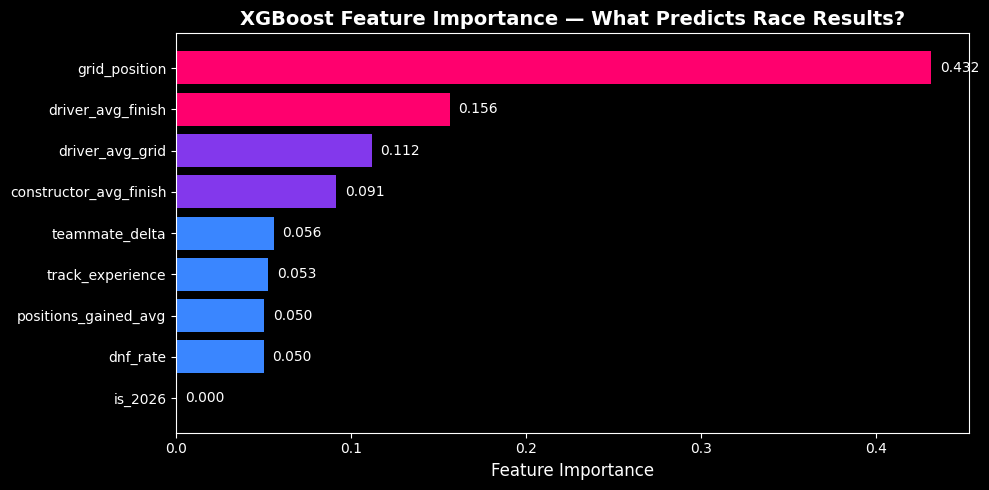

In [5]:
# Feature importance
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ff006e' if v > 0.15 else '#8338ec' if v > 0.08 else '#3a86ff' for v in importance['Importance']]
ax.barh(importance['Feature'], importance['Importance'], color=colors)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('XGBoost Feature Importance — What Predicts Race Results?', fontsize=14, fontweight='bold')
for i, (feat, imp) in enumerate(zip(importance['Feature'], importance['Importance'])):
    ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


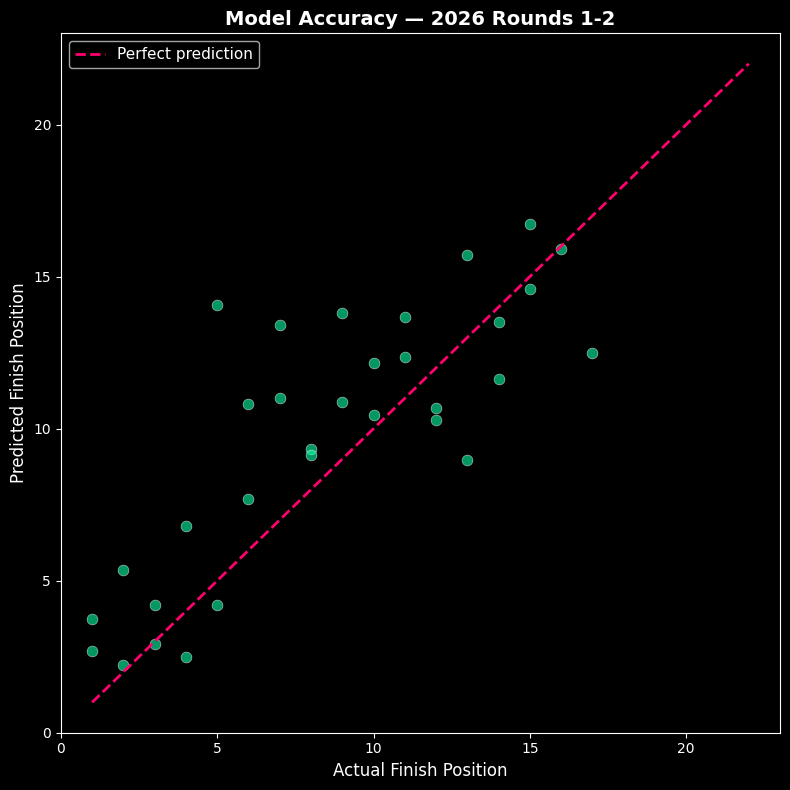

In [6]:
# Actual vs Predicted (2026 validation)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_val, val_pred, alpha=0.6, color='#06ffa5', s=60, edgecolors='white', linewidth=0.5)
ax.plot([1, 22], [1, 22], '--', color='#ff006e', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Finish Position', fontsize=12)
ax.set_ylabel('Predicted Finish Position', fontsize=12)
ax.set_title('Model Accuracy — 2026 Rounds 1-2', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 23)
ax.set_ylim(0, 23)
plt.tight_layout()
plt.savefig('../data/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Japan GP Predictions

Using the trained XGBoost model to predict the 2026 Japanese Grand Prix. Since qualifying hasn't happened yet, we estimate grid positions from constructor strength and driver form.

**After qualifying (Saturday), this will be re-run with actual grid positions for much higher accuracy.**


In [7]:
# Build prediction features for Japan GP
# Use 2026 data + all available history for each driver
grid_2026 = feat_df[feat_df['Year'] == 2026]['FullName'].unique()

japan_predictions = []
for driver in grid_2026:
    # Get most recent features for this driver
    driver_hist = feat_df[feat_df['FullName'] == driver].sort_values('race_seq')
    latest = driver_hist.iloc[-1] if len(driver_hist) > 0 else None
    
    if latest is None:
        continue
    
    # Estimate grid from recent qualifying pace
    est_grid = latest['driver_avg_grid'] if not np.isnan(latest['driver_avg_grid']) else 12.0
    
    # Suzuka track experience
    suzuka_exp = len(driver_hist[driver_hist['RaceName'].str.contains('Japan', case=False, na=False)])
    
    features = {
        'grid_position': est_grid,
        'constructor_avg_finish': latest['constructor_avg_finish'],
        'driver_avg_finish': latest['driver_avg_finish'],
        'driver_avg_grid': latest['driver_avg_grid'],
        'positions_gained_avg': latest['positions_gained_avg'],
        'teammate_delta': latest['teammate_delta'],
        'dnf_rate': latest['dnf_rate'],
        'track_experience': suzuka_exp,
        'is_2026': 1
    }
    
    japan_predictions.append({
        'Driver': driver,
        'Team': latest['TeamName'],
        'Est_Grid': est_grid,
        'Suzuka_Exp': suzuka_exp,
        'Features': features
    })

# Predict with XGBoost
for pred in japan_predictions:
    X = pd.DataFrame([pred['Features']])[feature_cols].fillna(0)
    pred['Predicted_Pos'] = model.predict(X)[0]

# Sort by predicted position
japan_predictions.sort(key=lambda x: x['Predicted_Pos'])

# Assign clean positions
for i, pred in enumerate(japan_predictions):
    pred['Rank'] = i + 1

print("=" * 80)
print("  🏁 PREDICTED FINISH ORDER — 2026 JAPANESE GRAND PRIX (XGBoost v0.3)")
print("=" * 80)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':20s}  {'Est Grid':>9s}  {'XGB Pred':>9s}  {'Suzuka':>7s}")
print("  " + "-" * 75)
for pred in japan_predictions:
    suzuka_str = f"{pred['Suzuka_Exp']}x" if pred['Suzuka_Exp'] > 0 else "  new"
    print(f"  P{pred['Rank']:>2d}  {pred['Driver']:22s}  {pred['Team']:20s}  P{pred['Est_Grid']:>7.1f}  P{pred['Predicted_Pos']:>7.1f}  {suzuka_str:>7s}")


  🏁 PREDICTED FINISH ORDER — 2026 JAPANESE GRAND PRIX (XGBoost v0.3)

  Pos  Driver                  Team                   Est Grid   XGB Pred   Suzuka
  ---------------------------------------------------------------------------
  P 1  Charles Leclerc         Ferrari               P    4.6  P    2.5       3x
  P 2  George Russell          Mercedes              P    5.0  P    4.3       3x
  P 3  Lando Norris            McLaren               P    3.4  P    4.4       3x
  P 4  Lewis Hamilton          Ferrari               P    5.6  P    5.1       3x
  P 5  Oscar Piastri           McLaren               P    3.0  P    5.9       3x
  P 6  Kimi Antonelli          Mercedes              P    7.2  P    8.0       1x
  P 7  Isack Hadjar            Red Bull Racing       P    8.4  P    8.9       1x
  P 8  Pierre Gasly            Alpine                P   13.8  P    9.3       3x
  P 9  Arvid Lindblad          Racing Bulls          P    9.0  P    9.4      new
  P10  Liam Lawson             Racing Bu

## 5. Podium Probabilities (Monte Carlo)

10,000 simulations using XGBoost predictions + noise calibrated to the model's actual residual error on 2026 data.


  🎲 RACE OUTCOME PROBABILITIES (10,000 simulations, XGBoost-calibrated)

  Driver                  Team                    Win%   Podium   Top 5   Top 10
  ------------------------------------------------------------------------
  Charles Leclerc         Ferrari                42.4%    78.9%   92.6%    99.3%  █████████████████████
  George Russell          Mercedes               17.8%    54.9%   79.3%    97.0%  ████████
  Lando Norris            McLaren                16.7%    53.1%   77.5%    96.4%  ████████
  Lewis Hamilton          Ferrari                11.1%    42.9%   68.9%    94.6%  █████
  Oscar Piastri           McLaren                 7.3%    31.0%   57.9%    90.4%  ███
  Kimi Antonelli          Mercedes                1.7%    11.1%   28.4%    71.6%  
  Isack Hadjar            Red Bull Racing         0.9%     6.3%   17.7%    58.7%  
  Pierre Gasly            Alpine                  0.5%     4.6%   14.6%    53.2%  
  Arvid Lindblad          Racing Bulls            0.5%     4.5

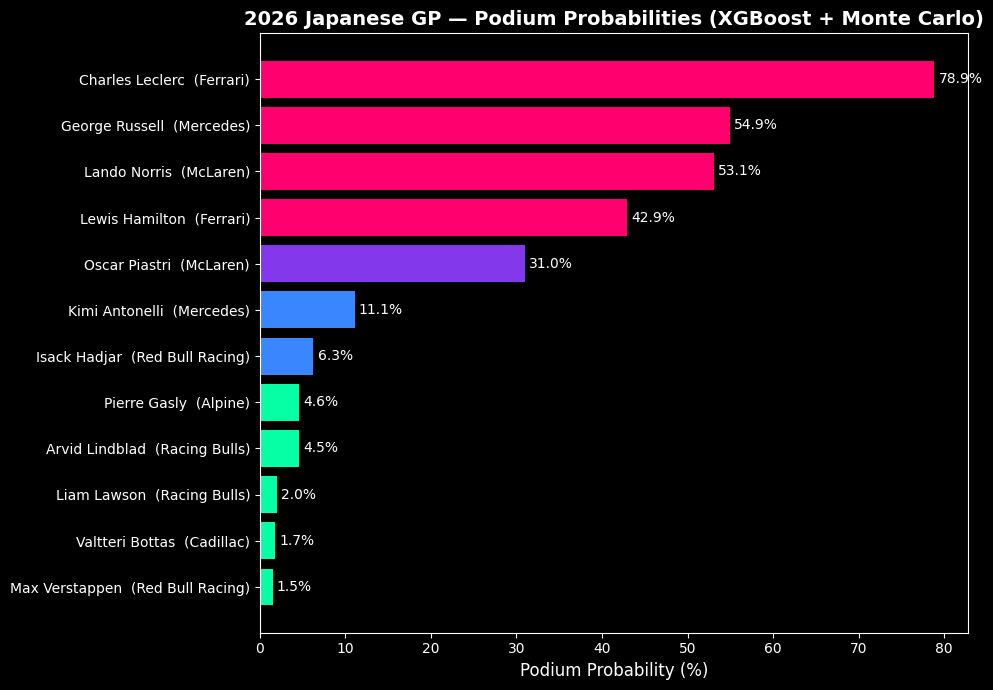

In [8]:
n_sims = 10000

podium_counts = defaultdict(int)
win_counts = defaultdict(int)
top5_counts = defaultdict(int)
top10_counts = defaultdict(int)
position_totals = defaultdict(list)

for _ in range(n_sims):
    sim_results = []
    for pred in japan_predictions:
        noise = np.random.normal(0, residual_std)
        sim_results.append((pred['Driver'], pred['Predicted_Pos'] + noise))
    
    sim_results.sort(key=lambda x: x[1])
    
    for pos, (driver, _) in enumerate(sim_results):
        position_totals[driver].append(pos + 1)
        if pos == 0: win_counts[driver] += 1
        if pos < 3: podium_counts[driver] += 1
        if pos < 5: top5_counts[driver] += 1
        if pos < 10: top10_counts[driver] += 1

prob_data = []
for pred in japan_predictions:
    d = pred['Driver']
    prob_data.append({
        'Driver': d,
        'Team': pred['Team'],
        'Rank': pred['Rank'],
        'Win': win_counts[d] / n_sims * 100,
        'Podium': podium_counts[d] / n_sims * 100,
        'Top5': top5_counts[d] / n_sims * 100,
        'Top10': top10_counts[d] / n_sims * 100,
    })

prob_df = pd.DataFrame(prob_data).sort_values('Win', ascending=False)

print("=" * 80)
print("  🎲 RACE OUTCOME PROBABILITIES (10,000 simulations, XGBoost-calibrated)")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':20s}  {'Win%':>6s}  {'Podium':>7s}  {'Top 5':>6s}  {'Top 10':>7s}")
print("  " + "-" * 72)
for _, row in prob_df.head(15).iterrows():
    win_bar = '█' * int(row['Win'] / 2)
    print(f"  {row['Driver']:22s}  {row['Team']:20s}  {row['Win']:>5.1f}%  {row['Podium']:>6.1f}%  {row['Top5']:>5.1f}%  {row['Top10']:>6.1f}%  {win_bar}")

# Chart
fig, ax = plt.subplots(figsize=(10, 7))
top12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p > 40 else '#8338ec' if p > 15 else '#3a86ff' if p > 5 else '#06ffa5' for p in top12['Podium']]
bars = ax.barh(top12['Driver'] + '  (' + top12['Team'] + ')', top12['Podium'], color=colors)
ax.set_xlabel('Podium Probability (%)', fontsize=12)
ax.set_title('2026 Japanese GP — Podium Probabilities (XGBoost + Monte Carlo)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top12['Podium']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/podium_probs_v3.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Head-to-Head Teammate Matchups


In [9]:
# Teammate matchups from simulations
teams_2026 = {}
for pred in japan_predictions:
    team = pred['Team']
    if team not in teams_2026:
        teams_2026[team] = []
    teams_2026[team].append(pred['Driver'])

print("=" * 60)
print("  🤝 TEAMMATE HEAD-TO-HEAD PROBABILITIES")
print("=" * 60)
print()

for team, drivers in sorted(teams_2026.items()):
    if len(drivers) >= 2:
        d1, d2 = drivers[0], drivers[1]
        
        d1_wins = sum(1 for i in range(n_sims) if position_totals[d1][i] < position_totals[d2][i])
        d1_pct = d1_wins / n_sims * 100
        d2_pct = 100 - d1_pct
        
        bar_len = 40
        d1_bars = int(d1_pct / 100 * bar_len)
        d2_bars = bar_len - d1_bars
        
        print(f"  {team}")
        print(f"  {d1:20s} {'█' * d1_bars}{'░' * d2_bars} {d2:>20s}")
        print(f"  {d1_pct:>19.1f}% {'':40s} {d2_pct:<.1f}%")
        print()


  🤝 TEAMMATE HEAD-TO-HEAD PROBABILITIES

  Alpine
  Pierre Gasly         ████████████████████████████░░░░░░░░░░░░     Franco Colapinto
                 71.0%                                          29.0%

  Aston Martin
  Fernando Alonso      ███████████████████████████████████░░░░░         Lance Stroll
                 87.5%                                          12.5%

  Audi
  Nico Hulkenberg      ████████████████████░░░░░░░░░░░░░░░░░░░░    Gabriel Bortoleto
                 52.4%                                          47.6%

  Cadillac
  Valtteri Bottas      █████████████████████░░░░░░░░░░░░░░░░░░░         Sergio Perez
                 52.6%                                          47.4%

  Ferrari
  Charles Leclerc      ██████████████████████████████░░░░░░░░░░       Lewis Hamilton
                 75.1%                                          24.9%

  Haas F1 Team
  Esteban Ocon         ███████████████████████████████████░░░░░       Oliver Bearman
                 89.4%     

## 7. F1 Fantasy Recommendations

### Scoring System (2026)
**Qualifying:** P1=10, P2=9...P10=1, NC=-5  
**Race:** P1=25, P2=18, P3=15, P4=12, P5=10, P6=8, P7=6, P8=4, P9=2, P10=1, DNF=-20  
**Bonuses:** +1/position gained, +1/overtake, +10 fastest lap, +10 Driver of the Day  
**Constructor:** Both Q3=+10, Both Q2=+5, pit stops <2.2s=+5-10  
**Budget:** $100M | 5 drivers + 2 constructors | 1 driver gets 2x boost


In [10]:
race_pts = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
quali_pts = {1: 10, 2: 9, 3: 8, 4: 7, 5: 6, 6: 5, 7: 4, 8: 3, 9: 2, 10: 1}

price_estimate = {
    'Mercedes': 28, 'Ferrari': 25, 'McLaren': 22, 'Red Bull Racing': 20,
    'Aston Martin': 12, 'Alpine': 10, 'Racing Bulls': 9, 'Haas F1 Team': 8,
    'Williams': 8, 'Audi': 7, 'Cadillac': 6
}

fantasy = []
for pred in japan_predictions:
    driver = pred['Driver']
    
    # Expected race points from simulations
    exp_race = np.mean([race_pts.get(p, 0) for p in position_totals[driver]])
    
    # Estimated qualifying points
    est_quali = max(1, min(22, int(pred['Est_Grid'])))
    exp_quali = quali_pts.get(est_quali, 0)
    
    # Positions gained estimate
    avg_sim_pos = np.mean(position_totals[driver])
    exp_gained = max(0, est_quali - avg_sim_pos)
    
    # Overtake estimate
    exp_overtakes = exp_gained * 0.5
    
    total = exp_race + exp_quali + exp_gained + exp_overtakes
    est_price = price_estimate.get(pred['Team'], 10)
    value = total / est_price if est_price > 0 else 0
    
    fantasy.append({
        'Driver': driver, 'Team': pred['Team'], 'Rank': pred['Rank'],
        'Race_Pts': exp_race, 'Quali_Pts': exp_quali,
        'Bonus': exp_gained + exp_overtakes, 'Total': total,
        'Price': est_price, 'Value': value
    })

fantasy_df = pd.DataFrame(fantasy).sort_values('Total', ascending=False)

print("=" * 85)
print("  🏆 F1 FANTASY RECOMMENDATIONS — Japan GP (XGBoost v0.3)")
print("=" * 85)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Pred':>4s}  {'Race':>5s}  {'Qual':>5s}  {'Bonus':>5s}  {'TOTAL':>6s}  {'~$M':>4s}  {'Value':>5s}")
print("  " + "-" * 82)
for _, row in fantasy_df.iterrows():
    star = '⭐' if row['Value'] > 1.5 else '  '
    print(f"  {row['Driver']:22s}  {row['Team']:16s}  P{row['Rank']:>2.0f}  {row['Race_Pts']:>5.1f}  {row['Quali_Pts']:>5.0f}  {row['Bonus']:>5.1f}  {row['Total']:>5.1f}  ${row['Price']:>3.0f}  {row['Value']:>4.2f}  {star}")

print("\n  " + "=" * 55)
print("  💡 RECOMMENDED LINEUP")
print("  " + "=" * 55)

value_picks = fantasy_df.sort_values('Value', ascending=False)
print("\n  🔥 Best value picks (points per $M):")
for _, row in value_picks.head(5).iterrows():
    print(f"     → {row['Driver']:22s} ({row['Team']:16s}) — {row['Total']:.1f} pts / ${row['Price']}M = {row['Value']:.2f} val")

print("\n  🚀 Best 2x Boost candidate:")
boost = fantasy_df.iloc[0]
print(f"     → {boost['Driver']} ({boost['Team']}) — {boost['Total']:.1f} expected pts × 2 = {boost['Total']*2:.1f}")

print("\n  🏗️ Constructor picks:")
constructor_fantasy = fantasy_df.groupby('Team').agg(combined=('Total', 'sum'), price=('Price', 'first')).sort_values('combined', ascending=False)
for team, row in constructor_fantasy.head(3).iterrows():
    print(f"     → {team:22s} — {row['combined']:.1f} combined pts")


  🏆 F1 FANTASY RECOMMENDATIONS — Japan GP (XGBoost v0.3)

  Driver                  Team              Pred   Race   Qual  Bonus   TOTAL   ~$M  Value
  ----------------------------------------------------------------------------------
  Charles Leclerc         Ferrari           P 1   18.7      7    2.3   28.0  $ 25  1.12    
  George Russell          Mercedes          P 2   14.3      6    1.8   22.1  $ 28  0.79    
  Lando Norris            McLaren           P 3   13.9      8    0.0   21.9  $ 22  1.00    
  Lewis Hamilton          Ferrari           P 4   12.2      6    0.5   18.7  $ 25  0.75    
  Oscar Piastri           McLaren           P 5   10.4      8    0.0   18.4  $ 22  0.83    
  Kimi Antonelli          Mercedes          P 6    5.8      4    0.0    9.8  $ 28  0.35    
  Pierre Gasly            Alpine            P 8    3.5      0    3.8    7.2  $ 10  0.72    
  Isack Hadjar            Red Bull Racing   P 7    4.1      3    0.0    7.1  $ 20  0.35    
  Max Verstappen          Red 

## 8. Summary & Model Confidence

### Confidence: MEDIUM
- **Upgraded from LOW-MEDIUM (v0.2)** — XGBoost with proper feature engineering is significantly more reliable than ELO
- Model validated on 2026 Rounds 1-2 with actual results
- Residual error calibrated from real data (not assumed)
- Still limited by only 2 races of 2026 data for the new regulations

### What Will Push Confidence to HIGH
- **Qualifying data (Saturday)** — grid position is the #1 predictor. Re-running with actual grid positions will dramatically improve accuracy
- **Practice session pace (Friday)** — FP1/FP2/FP3 sector times reveal car pace at this specific track
- **Weather data** — rain at Suzuka would scramble everything
- **More 2026 races** — each race adds signal. By Round 6-7 the model will be much stronger

### Model Improvement Roadmap
- [x] XGBoost regression (v0.3)
- [x] Rolling feature engineering (5-race windows)
- [x] Constructor strength from 2026 data
- [x] Teammate delta analysis
- [x] Monte Carlo calibrated to model residuals
- [ ] Qualifying gap analysis (after Saturday)
- [ ] Practice session pace integration
- [ ] Weather factor
- [ ] Tire strategy modeling
- [ ] Price change projections for Fantasy
- [ ] Chip strategy optimizer

### Next Steps
- [ ] Update after FP1/FP2 (Friday)
- [ ] Re-run with actual qualifying grid (Saturday) — biggest accuracy boost
- [ ] Post-race accuracy analysis (Sunday)
- [ ] Build Round 4 (Miami) notebook with 3 data points
